<a href="https://colab.research.google.com/github/kursatkara/MAE_5020_Spring_2026/blob/master/06_Notebook_E.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Notebook E — In-Class Exercise: Debugging, Design Choices, and Interpretation

## 🎯 Learning Objective

Use the ideas from the previous notebooks to reason actively about neural-network behavior.

In this notebook, you will:

- inspect a training workflow critically,
- identify and correct implementation issues,
- compare different design choices,
- explain the observed behavior in words, not just plots.

---

## 🧠 Challenge

Up to this point, the notebooks were mostly guided.

That was intentional:
- Notebook A established trust in backpropagation,
- Notebook B interpreted training as a dynamical system,
- Notebook C introduced generalization,
- Notebook D demonstrated a cleaner PyTorch workflow.

Now the emphasis changes.

> You are no longer only a reader of notebooks.  
> You are the model designer and the debugger.

The purpose of this notebook is not just to obtain a low loss.  
The purpose is to practice **diagnosis, reasoning, and explanation**.



## 🔹 Recommended Class Workflow

This notebook works well in class if students proceed in the following order:

1. Read the challenge statement carefully.
2. Run the baseline code and inspect the outputs.
3. Answer the prompt questions before changing anything.
4. Make one change at a time.
5. Re-run and interpret the effect of that change.
6. Record short written conclusions.

This mirrors good scientific practice:
- form a hypothesis,
- make a controlled change,
- observe the result,
- interpret it.


In [1]:

import torch
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(11)
np.random.seed(11)

plt.rcParams["figure.figsize"] = (7, 4)



## 🔹 Dataset

We again use a simple one-dimensional regression problem:
$$
y = x^2 + \epsilon,
$$
with noisy samples.

This keeps the problem visually interpretable so that the focus remains on debugging and model behavior.


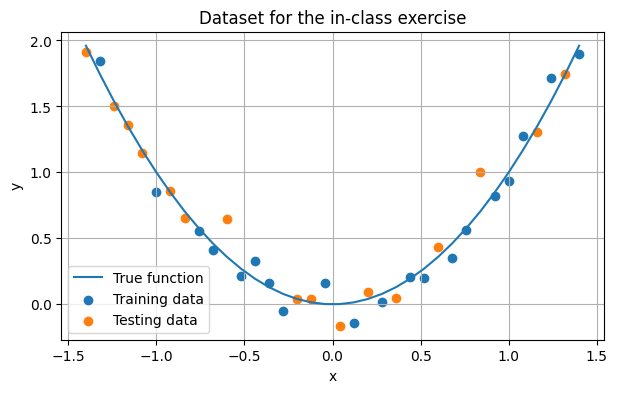

In [2]:

# Generate dataset
N = 36
x_all = torch.linspace(-1.4, 1.4, N).unsqueeze(1)
y_true_all = x_all**2
noise = 0.10 * torch.randn_like(x_all)
y_all = y_true_all + noise

perm = torch.randperm(N)
train_idx = perm[:20]
test_idx = perm[20:]

x_train_raw = x_all[train_idx]
y_train = y_all[train_idx]

x_test_raw = x_all[test_idx]
y_test = y_all[test_idx]

def sort_xy(x, y):
    idx = torch.argsort(x[:, 0])
    return x[idx], y[idx]

x_train_raw, y_train = sort_xy(x_train_raw, y_train)
x_test_raw, y_test = sort_xy(x_test_raw, y_test)
x_all_sorted, y_all_sorted = sort_xy(x_all, y_all)
_, y_true_sorted = sort_xy(x_all, y_true_all)

# Normalize using training statistics only
x_mean = x_train_raw.mean(dim=0, keepdim=True)
x_std = x_train_raw.std(dim=0, keepdim=True)

x_train = (x_train_raw - x_mean) / x_std
x_test = (x_test_raw - x_mean) / x_std

plt.figure()
plt.plot(x_all_sorted.numpy(), y_true_sorted.numpy(), label="True function")
plt.scatter(x_train_raw.numpy(), y_train.numpy(), label="Training data")
plt.scatter(x_test_raw.numpy(), y_test.numpy(), label="Testing data")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Dataset for the in-class exercise")
plt.legend()
plt.grid(True)
plt.show()



## 🔹 Baseline Model

We will use a simple one-hidden-layer regression network:
$$
z^1 = W^1 x + b^1,
$$
$$
a^1 = \phi(z^1),
$$
$$
\hat{y} = W^2 a^1 + b^2.
$$

The goal is not to find the “best” architecture.

The goal is to reason about how architecture and training choices affect the results.


In [3]:

class ExerciseRegressor(torch.nn.Module):
    def __init__(self, hidden_width=10, activation_name="tanh"):
        super().__init__()
        self.fc1 = torch.nn.Linear(1, hidden_width)
        self.fc2 = torch.nn.Linear(hidden_width, 1)
        self.activation_name = activation_name

    def activation(self, z):
        if self.activation_name == "tanh":
            return torch.tanh(z)
        elif self.activation_name == "relu":
            return torch.relu(z)
        elif self.activation_name == "sigmoid":
            return torch.sigmoid(z)
        else:
            raise ValueError("Unsupported activation.")

    def forward(self, x):
        z1 = self.fc1(x)
        a1 = self.activation(z1)
        y_hat = self.fc2(a1)
        return y_hat



## 🔹 A Baseline Training Function

This function is intentionally straightforward and readable.

Your task is to inspect the outputs, then modify selected settings in a controlled way.

You should not try to change everything at once.

Instead, treat each experiment as a small scientific study.


In [4]:

def train_and_evaluate(hidden_width=10, activation_name="tanh", lr=0.05, epochs=1200):
    torch.manual_seed(21)

    model = ExerciseRegressor(hidden_width=hidden_width, activation_name=activation_name)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = torch.nn.MSELoss()

    history = {
        "epoch": [],
        "train_loss": [],
        "test_loss": [],
        "grad_norm": [],
    }

    for epoch in range(epochs):
        model.train()

        y_train_hat = model(x_train)
        train_loss = loss_fn(y_train_hat, y_train)

        optimizer.zero_grad()
        train_loss.backward()

        grad_sq_sum = 0.0
        for p in model.parameters():
            if p.grad is not None:
                grad_sq_sum += torch.sum(p.grad**2).item()
        grad_norm = np.sqrt(grad_sq_sum)

        optimizer.step()

        model.eval()
        with torch.no_grad():
            y_test_hat = model(x_test)
            test_loss = loss_fn(y_test_hat, y_test)

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss.item())
        history["test_loss"].append(test_loss.item())
        history["grad_norm"].append(grad_norm)

    return model, history



## 🔹 Part 1 — Run the Baseline Case

Start with the baseline configuration:

- hidden width = 10
- activation = `tanh`
- learning rate = 0.05

Before changing anything, inspect:

- final training loss,
- final testing loss,
- loss curves,
- gradient norm,
- predicted function.

### Prompt

Before moving on, write one or two sentences answering:

1. Does the baseline model appear to fit the data reasonably?
2. Is there any obvious evidence of instability or overfitting?


In [5]:

model_base, hist_base = train_and_evaluate(
    hidden_width=10,
    activation_name="tanh",
    lr=0.05,
    epochs=1200,
)

print("Final training loss:", hist_base["train_loss"][-1])
print("Final testing loss :", hist_base["test_loss"][-1])


Final training loss: 0.01259149145334959
Final testing loss : 0.015468122437596321


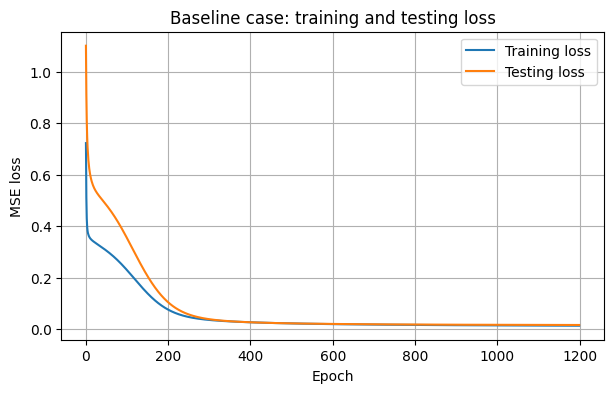

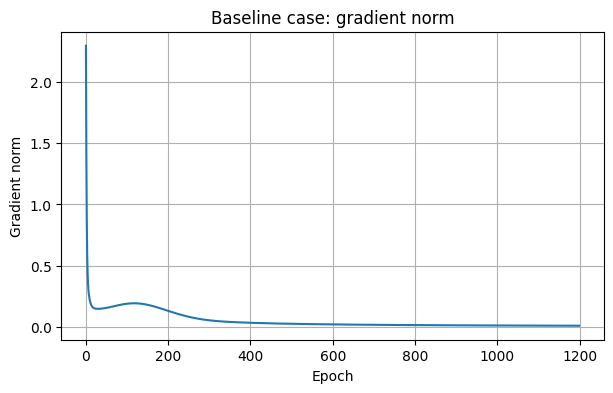

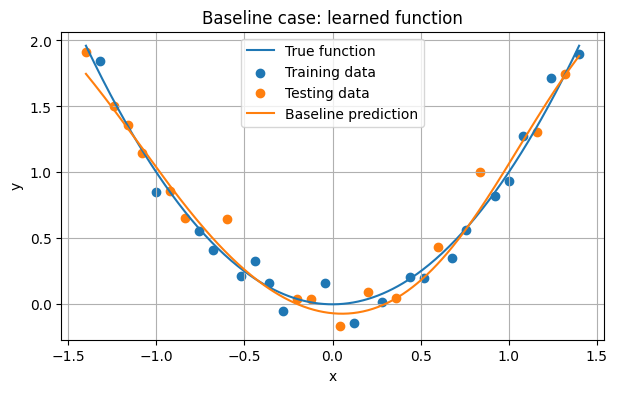

In [6]:

plt.figure()
plt.plot(hist_base["epoch"], hist_base["train_loss"], label="Training loss")
plt.plot(hist_base["epoch"], hist_base["test_loss"], label="Testing loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Baseline case: training and testing loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(hist_base["epoch"], hist_base["grad_norm"])
plt.xlabel("Epoch")
plt.ylabel("Gradient norm")
plt.title("Baseline case: gradient norm")
plt.grid(True)
plt.show()

x_plot_raw = torch.linspace(-1.4, 1.4, 300).unsqueeze(1)
x_plot = (x_plot_raw - x_mean) / x_std
y_plot_true = x_plot_raw**2

with torch.no_grad():
    y_plot_base = model_base(x_plot)

plt.figure()
plt.plot(x_plot_raw.numpy(), y_plot_true.numpy(), label="True function")
plt.scatter(x_train_raw.numpy(), y_train.numpy(), label="Training data")
plt.scatter(x_test_raw.numpy(), y_test.numpy(), label="Testing data")
plt.plot(x_plot_raw.numpy(), y_plot_base.numpy(), label="Baseline prediction")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Baseline case: learned function")
plt.legend()
plt.grid(True)
plt.show()



## 🔍 Sanity Check

Before changing the model, verify:

- Is the training loss decreasing?
- Is the testing loss of similar order to the training loss?
- Is the learned function smooth and plausible?
- Is the gradient norm shrinking over time?

These checks should become automatic habits.



## 🔹 Part 2 — Learning Rate Experiment

Now study the effect of the learning rate $\eta$.

Try the following values:

- small: `lr = 0.005`
- baseline: `lr = 0.05`
- large: `lr = 0.5`

### Prompt

For each case, ask:

1. How fast does the loss decrease?
2. Is the optimization stable?
3. Does the model reach a reasonable final fit?
4. What happens to the gradient norm?

Do not just say “this one is better.”  
Explain **why** the behavior changes.


In [7]:

model_lr_small, hist_lr_small = train_and_evaluate(
    hidden_width=10,
    activation_name="tanh",
    lr=0.005,
    epochs=1200,
)

model_lr_med, hist_lr_med = train_and_evaluate(
    hidden_width=10,
    activation_name="tanh",
    lr=0.05,
    epochs=1200,
)

model_lr_large, hist_lr_large = train_and_evaluate(
    hidden_width=10,
    activation_name="tanh",
    lr=0.5,
    epochs=1200,
)


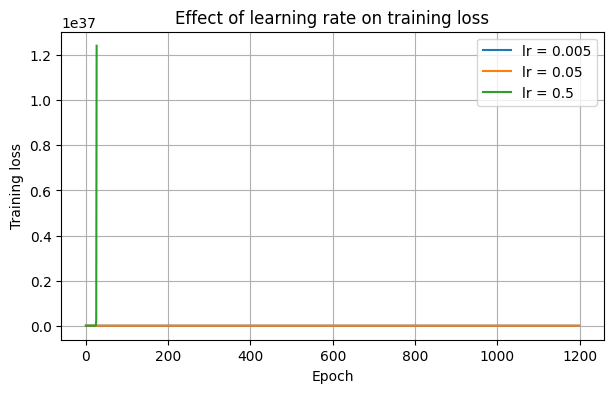

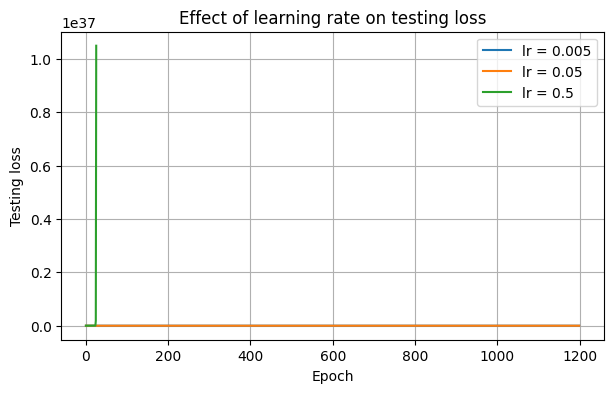

In [8]:

plt.figure()
plt.plot(hist_lr_small["epoch"], hist_lr_small["train_loss"], label="lr = 0.005")
plt.plot(hist_lr_med["epoch"], hist_lr_med["train_loss"], label="lr = 0.05")
plt.plot(hist_lr_large["epoch"], hist_lr_large["train_loss"], label="lr = 0.5")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Effect of learning rate on training loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(hist_lr_small["epoch"], hist_lr_small["test_loss"], label="lr = 0.005")
plt.plot(hist_lr_med["epoch"], hist_lr_med["test_loss"], label="lr = 0.05")
plt.plot(hist_lr_large["epoch"], hist_lr_large["test_loss"], label="lr = 0.5")
plt.xlabel("Epoch")
plt.ylabel("Testing loss")
plt.title("Effect of learning rate on testing loss")
plt.legend()
plt.grid(True)
plt.show()



## 🔹 Part 3 — Activation Function Experiment

Next, compare three activation functions:

- `tanh`
- `relu`
- `sigmoid`

Use the same hidden width and learning rate for all three cases.

### Prompt

As you compare them, think about:

1. Which activation leads to the best fit here?
2. Which activation leads to slower learning?
3. Which activation produces the smoothest regression curve?
4. Why might the behavior differ even though the rest of the model is unchanged?


In [9]:

model_tanh, hist_tanh = train_and_evaluate(
    hidden_width=10,
    activation_name="tanh",
    lr=0.05,
    epochs=1200,
)

model_relu, hist_relu = train_and_evaluate(
    hidden_width=10,
    activation_name="relu",
    lr=0.05,
    epochs=1200,
)

model_sigmoid, hist_sigmoid = train_and_evaluate(
    hidden_width=10,
    activation_name="sigmoid",
    lr=0.05,
    epochs=1200,
)


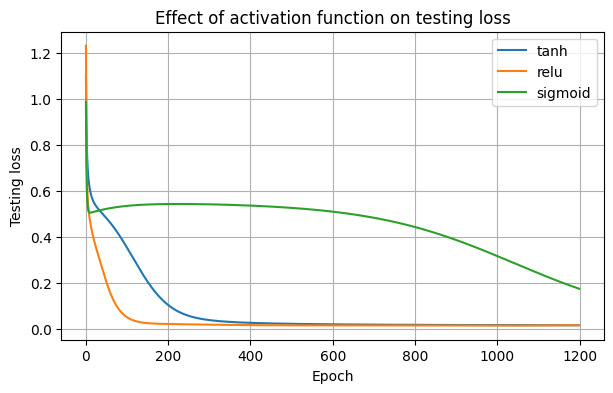

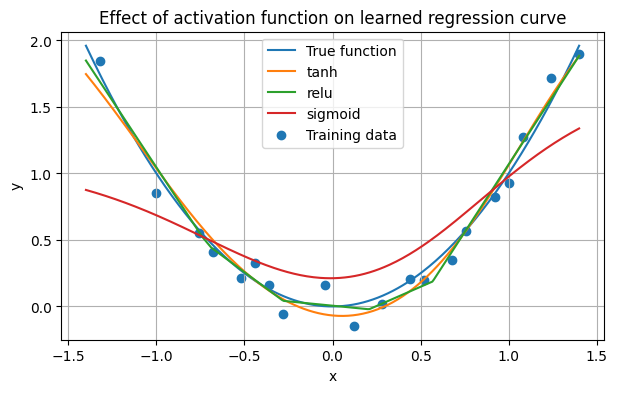

In [10]:

plt.figure()
plt.plot(hist_tanh["epoch"], hist_tanh["test_loss"], label="tanh")
plt.plot(hist_relu["epoch"], hist_relu["test_loss"], label="relu")
plt.plot(hist_sigmoid["epoch"], hist_sigmoid["test_loss"], label="sigmoid")
plt.xlabel("Epoch")
plt.ylabel("Testing loss")
plt.title("Effect of activation function on testing loss")
plt.legend()
plt.grid(True)
plt.show()

with torch.no_grad():
    y_plot_tanh = model_tanh(x_plot)
    y_plot_relu = model_relu(x_plot)
    y_plot_sigmoid = model_sigmoid(x_plot)

plt.figure()
plt.plot(x_plot_raw.numpy(), y_plot_true.numpy(), label="True function")
plt.plot(x_plot_raw.numpy(), y_plot_tanh.numpy(), label="tanh")
plt.plot(x_plot_raw.numpy(), y_plot_relu.numpy(), label="relu")
plt.plot(x_plot_raw.numpy(), y_plot_sigmoid.numpy(), label="sigmoid")
plt.scatter(x_train_raw.numpy(), y_train.numpy(), label="Training data")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Effect of activation function on learned regression curve")
plt.legend()
plt.grid(True)
plt.show()



## 🔹 Part 4 — Model Capacity Experiment

Now vary the hidden width:

- width = 1
- width = 10
- width = 50

Keep the activation and learning rate fixed.

### Prompt

As you compare the results, ask:

1. Does the smallest model underfit?
2. Does the largest model begin to fit noise?
3. Which width provides the best balance between flexibility and generalization?


In [11]:

model_w1, hist_w1 = train_and_evaluate(
    hidden_width=1,
    activation_name="tanh",
    lr=0.05,
    epochs=1200,
)

model_w10, hist_w10 = train_and_evaluate(
    hidden_width=10,
    activation_name="tanh",
    lr=0.05,
    epochs=1200,
)

model_w50, hist_w50 = train_and_evaluate(
    hidden_width=50,
    activation_name="tanh",
    lr=0.05,
    epochs=1200,
)


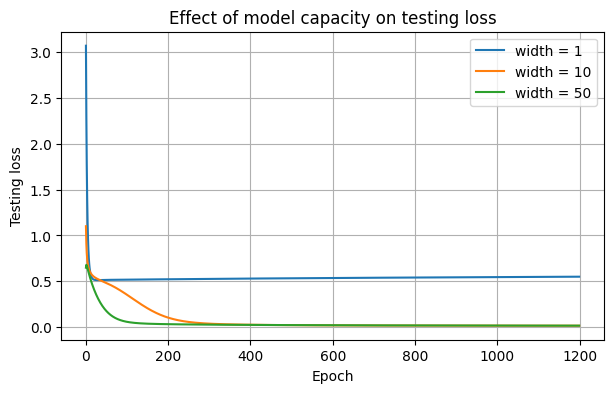

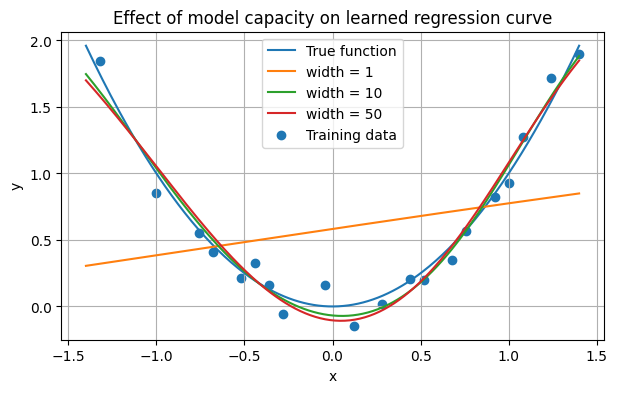

In [12]:

plt.figure()
plt.plot(hist_w1["epoch"], hist_w1["test_loss"], label="width = 1")
plt.plot(hist_w10["epoch"], hist_w10["test_loss"], label="width = 10")
plt.plot(hist_w50["epoch"], hist_w50["test_loss"], label="width = 50")
plt.xlabel("Epoch")
plt.ylabel("Testing loss")
plt.title("Effect of model capacity on testing loss")
plt.legend()
plt.grid(True)
plt.show()

with torch.no_grad():
    y_plot_w1 = model_w1(x_plot)
    y_plot_w10 = model_w10(x_plot)
    y_plot_w50 = model_w50(x_plot)

plt.figure()
plt.plot(x_plot_raw.numpy(), y_plot_true.numpy(), label="True function")
plt.plot(x_plot_raw.numpy(), y_plot_w1.numpy(), label="width = 1")
plt.plot(x_plot_raw.numpy(), y_plot_w10.numpy(), label="width = 10")
plt.plot(x_plot_raw.numpy(), y_plot_w50.numpy(), label="width = 50")
plt.scatter(x_train_raw.numpy(), y_train.numpy(), label="Training data")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Effect of model capacity on learned regression curve")
plt.legend()
plt.grid(True)
plt.show()



## 🔹 Part 5 — Short Written Synthesis

Write a short response answering the following:

1. Which learning rate gave the best overall behavior, and why?
2. Which activation function worked best for this regression problem, and why?
3. Which hidden width gave the best balance between fit and generalization?
4. What is one concrete lesson you learned about debugging or diagnosing training behavior?

Your answer should be based on evidence from the plots and numerical outputs.

A good answer is not long.  
A good answer is clear, specific, and justified.



## 🔹 Optional Debugging Challenge

Below is a deliberately broken training loop.  
Do **not** trust it automatically.

Read it carefully and identify what is wrong.

Possible issues to look for include:
- missing gradient reset,
- wrong training/evaluation sequence,
- misuse of normalized vs raw inputs,
- incorrect optimizer placement.

You may discuss the issue in class before fixing it.


In [13]:

# Deliberately broken example for discussion
def broken_train_loop():
    torch.manual_seed(21)
    model = ExerciseRegressor(hidden_width=10, activation_name="tanh")
    optimizer = torch.optim.SGD(model.parameters(), lr=0.05)
    loss_fn = torch.nn.MSELoss()

    losses = []

    for epoch in range(200):
        # Problem 1: using raw inputs even though the main workflow uses normalized inputs
        y_hat = model(x_train_raw)

        loss = loss_fn(y_hat, y_train)

        # Problem 2: backward is called, but gradients are never cleared
        loss.backward()

        # Problem 3: optimizer step occurs, but gradient accumulation is uncontrolled
        optimizer.step()

        losses.append(loss.item())

    return losses

# Uncomment the lines below only after discussing the problems.
# bad_losses = broken_train_loop()
# plt.plot(bad_losses)
# plt.title("Broken training loop")
# plt.grid(True)
# plt.show()



## 🔹 Reflection Questions

1. Why is it important to change only one modeling choice at a time when running experiments?
2. Why can two models with similar training loss behave differently on the test set?
3. Why is debugging a neural network not just a coding task, but also a modeling task?
4. Which diagnostic plot did you find most informative: loss, gradient norm, or prediction curve? Why?
5. If this were a real aerospace dataset, what additional validation checks would you want?

These questions are meant to build the habit of scientific interpretation.



## 🧠 Engineering Takeaway

A neural network should be treated as a model that must be:
- implemented carefully,
- trained thoughtfully,
- evaluated critically,
- interpreted honestly.

In practice, many modeling failures do not come from sophisticated mathematics.  
They come from:
- careless preprocessing,
- poor hyperparameter choices,
- failure to separate training and testing,
- lack of sanity checks.

That is why debugging and interpretation are essential parts of scientific machine learning.



## ✅ End-of-Notebook Checklist

Before you finish, make sure you can answer:

- What does the learning rate control?
- Why does activation choice matter?
- How does model capacity affect underfitting and overfitting?
- Why are train/test comparisons necessary?
- What are the most important sanity checks in a training workflow?

If you can answer those questions clearly, then you are not just running neural networks — you are beginning to understand them.
